## Рубежный контроль №1

Тенишев Александр ИУ5-65Б 

Вариант 18

Задача 3

Набор данных, указанного в задачах 2 https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_wine.html#sklearn.datasets.load_wine

In [63]:
from sklearn.datasets import load_wine
import pandas as pd

In [64]:
df = load_wine()
data = pd.DataFrame(df.data, columns=df.feature_names)

In [65]:
# размер набора данных
data.shape

(178, 13)

In [66]:
# типы колонок
data.dtypes

alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
dtype: object

In [67]:
# Первые 5 строк датасета
data.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [68]:
data.isnull().sum()

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64

## ЗАДАЧА 3

Для заданного набора данных произведите масштабирование данных (для одного признака) и преобразование категориальных признаков в количественные двумя способами (label encoding, one hot encoding) для одного признака. Какие методы Вы использовали для решения задачи и почему?

In [69]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

data['proline_scaled'] = scaler.fit_transform(data[['proline']])

In [70]:
data.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,proline_scaled
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0.561341
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0.550642
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0.646933
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0.857347
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0.325963


Создание искусственного категориального признака (требуется по заданию). Разделим содержание алкоголя на три категории:

In [71]:
data['alcohol_category'] = pd.cut(
    data['alcohol'],
    bins=3,
    labels=['low', 'medium', 'high']
)

print(data[['alcohol', 'alcohol_category']].head(100))

    alcohol alcohol_category
0     14.23             high
1     13.20           medium
2     13.16           medium
3     14.37             high
4     13.24           medium
..      ...              ...
95    12.47           medium
96    11.81              low
97    12.29              low
98    12.37           medium
99    12.29              low

[100 rows x 2 columns]


In [72]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data['alcohol_label'] = le.fit_transform(data['alcohol_category'])

print(data[['alcohol_category', 'alcohol_label']].head(100))

   alcohol_category  alcohol_label
0              high              0
1            medium              2
2            medium              2
3              high              0
4            medium              2
..              ...            ...
95           medium              2
96              low              1
97              low              1
98           medium              2
99              low              1

[100 rows x 2 columns]


In [73]:
print(type(data))

<class 'pandas.DataFrame'>


In [74]:
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)

encoded = encoder.fit_transform(data[['alcohol_category']])

encoded_data = pd.DataFrame(
    encoded,
    columns=encoder.get_feature_names_out(['alcohol_category']),
    index=data.index
)

data = pd.concat([data, encoded_data], axis=1)

print(data.filter(like='alcohol_category').head(100))

   alcohol_category  alcohol_category_high  alcohol_category_low  \
0              high                    1.0                   0.0   
1            medium                    0.0                   0.0   
2            medium                    0.0                   0.0   
3              high                    1.0                   0.0   
4            medium                    0.0                   0.0   
..              ...                    ...                   ...   
95           medium                    0.0                   0.0   
96              low                    0.0                   1.0   
97              low                    0.0                   1.0   
98           medium                    0.0                   0.0   
99              low                    0.0                   1.0   

    alcohol_category_medium  
0                       0.0  
1                       1.0  
2                       1.0  
3                       0.0  
4                       1.0  
.. 

Для студентов группы ИУ5-65Б, ИУ5-66Б, ИУ5И-61Б - для набора данных построить "парные диаграммы".

In [78]:
import seaborn as sns
import matplotlib.pyplot as plt
data['target'] = load_wine().target


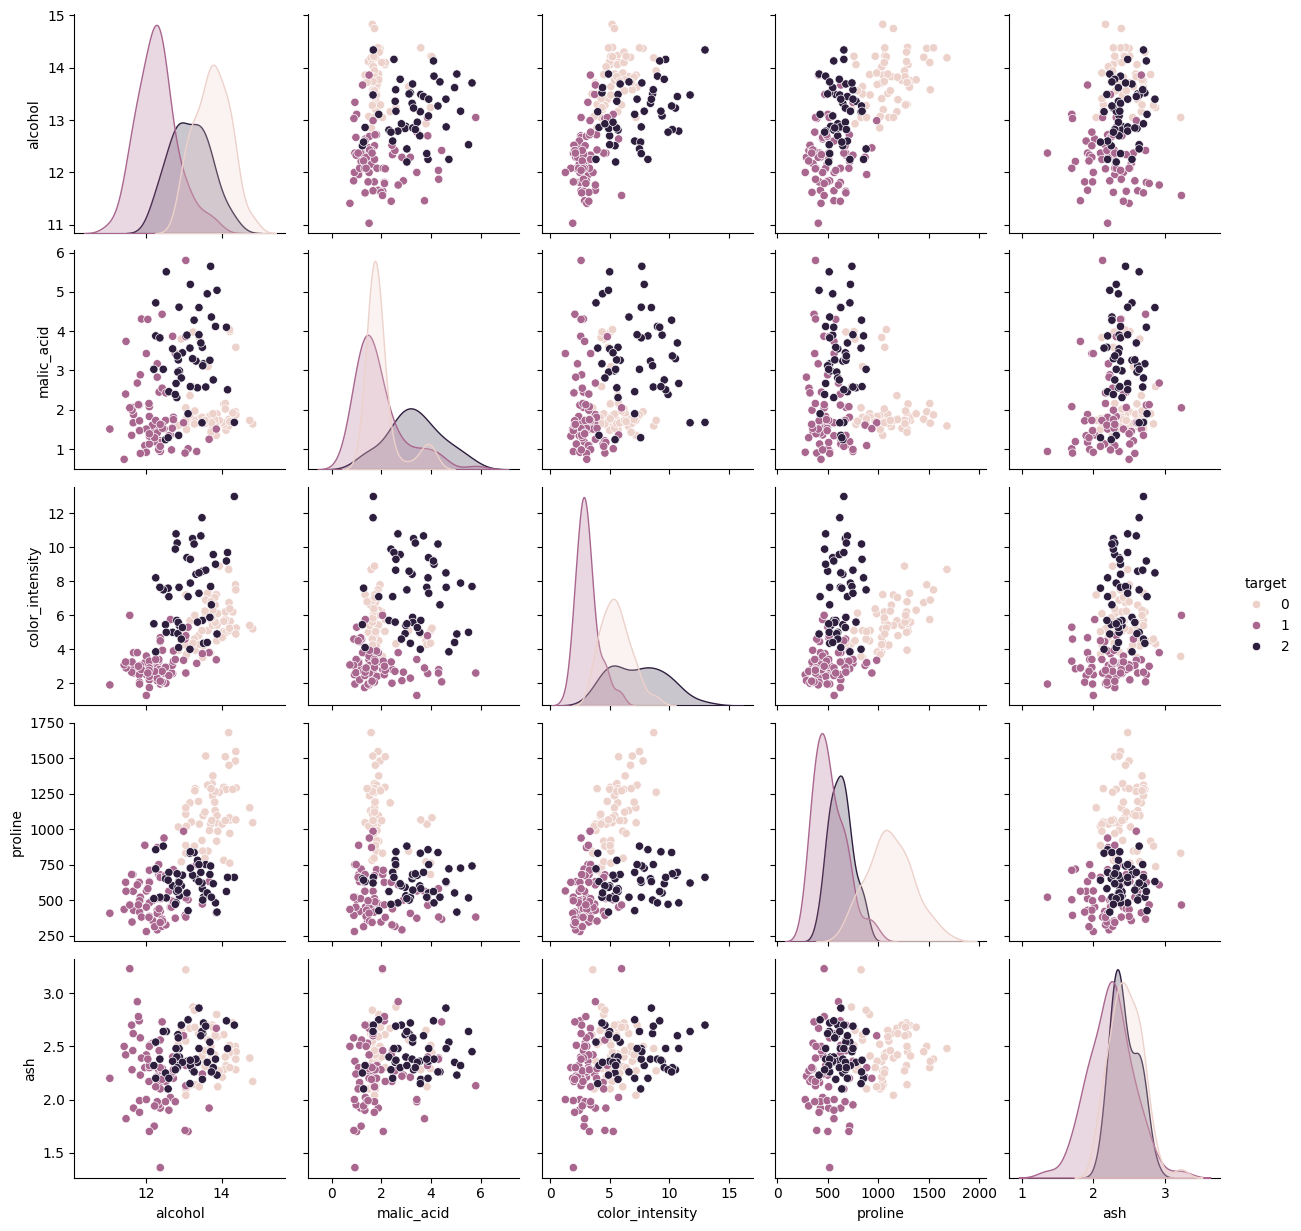

In [79]:
cols = ['alcohol', 'malic_acid', 'color_intensity', 'proline', 'ash']

sns.pairplot(data[cols + ['target']], hue='target')
plt.show()

Масштабирование признака — MinMaxScaler

Приводит значения признака proline к диапазону [0, 1].

Почему использовали:
- признаки в датасете имеют разные масштабы

например:
- alcohol ≈ 10–15
- proline ≈ сотни/тысячи

без масштабирования модели могут “перекоситься” в сторону больших чисел

Label Encoding

Преобразует категории:

- low → 0
- medium → 1
- high → 2


Почему использовали:
- нужно получить числовое представление категорий
- удобно для моделей, которые работают с числами напрямую

Ограничение:

Label encoding вводит искусственный порядок, которого может не быть

One-Hot Encoding

Создаёт отдельные бинарные признаки:

- low → [1,0,0]
- medium → [0,1,0]
- high → [0,0,1]


Почему использовали:
- чтобы убрать ложный порядок между категориями
- делает категории независимыми
- улучшает качество моделей, чувствительных к расстояниям и линейности